In [1]:
import pandas as pd
import numpy as np
import sys
import os

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from noventis.eda_auto import NoventisAutoEDA
from noventis import data_cleaner
from noventis.predictor import NoventisAutoML

# Create a "dirty" sample DataFrame
data = {
    'Age': [22, 38, 26, 35, np.nan, 28, 50, 45],
    'City': ['London', 'Paris', 'New York', 'Tokyo', 'London', 'Paris', np.nan, 'New York'],
    'Experience': [1, 10, 3, 8, 5, 4, 20, 15],
    'Salary': [72000, 48000, 54000, 250000, 75000, np.nan, 83000, 45000], # 250000 is an outlier
    'Purchased': [0, 1, 0, 1, 1, 0, 1, 0] # Our target
}
df = pd.DataFrame(data)

print("Initial Data:")
display(df)


Initial Data:


,Age,City,Experience,Salary,Purchased
0,22.0,London,1,72000.0,0
1,38.0,Paris,10,48000.0,1
2,26.0,New York,3,54000.0,0
3,35.0,Tokyo,8,250000.0,1
4,NaN,London,5,75000.0,1
5,28.0,Paris,4,NaN,0
6,50.0,NaN,20,83000.0,1
7,45.0,New York,15,45000.0,0


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Generating EDA report with 'default' personality, please wait...
Report generated successfully. Displaying below.



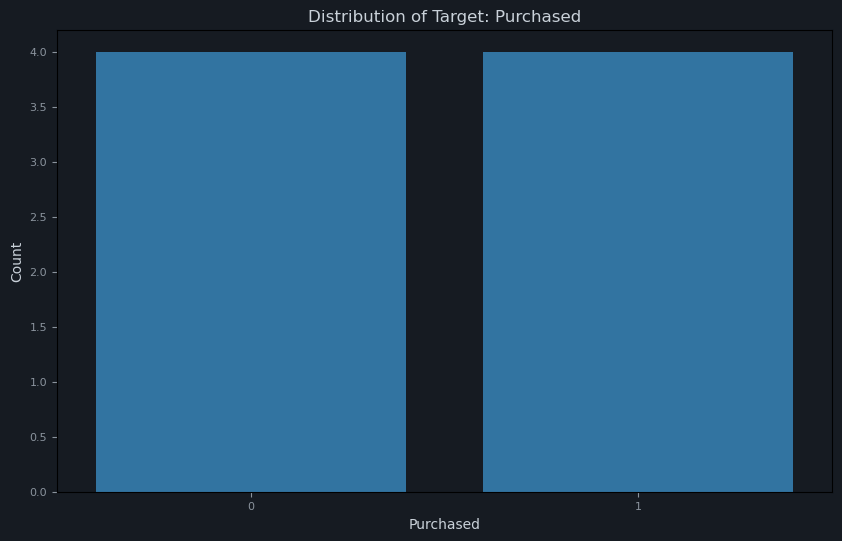
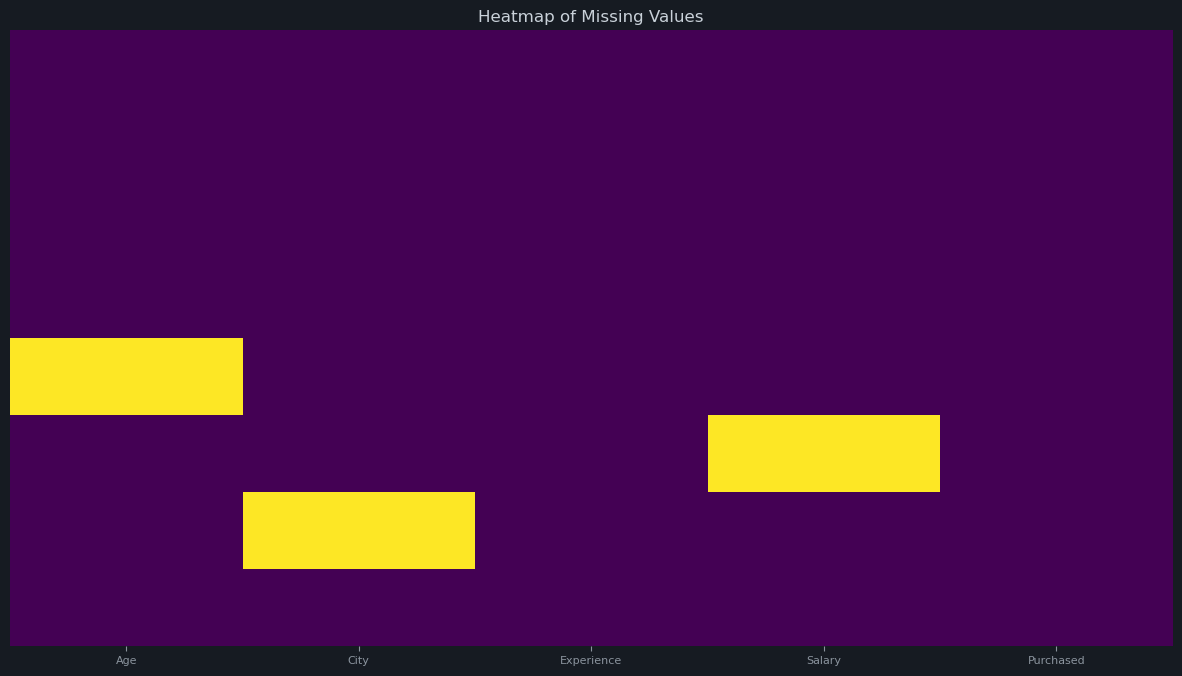
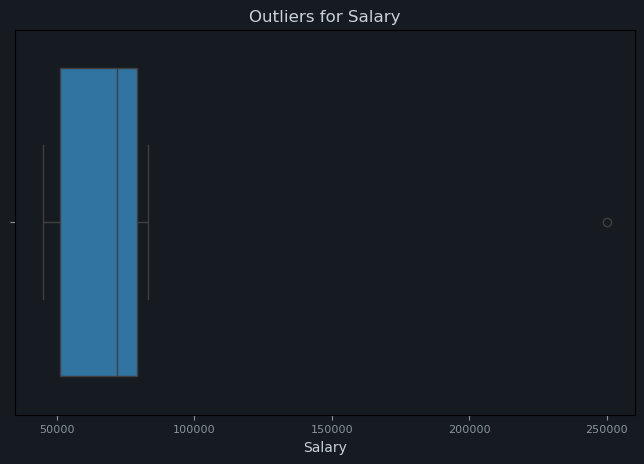
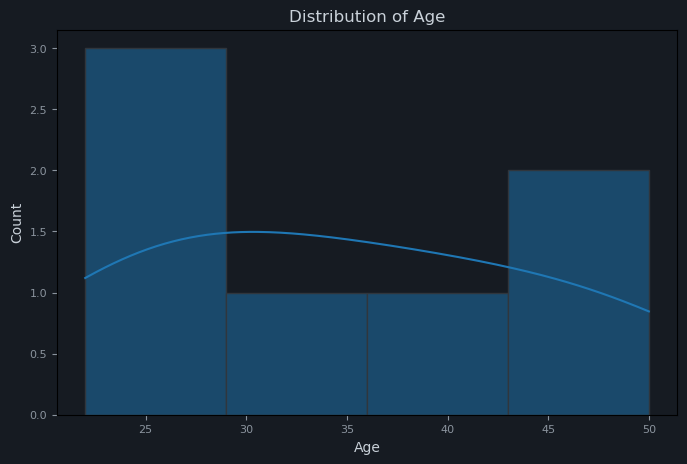
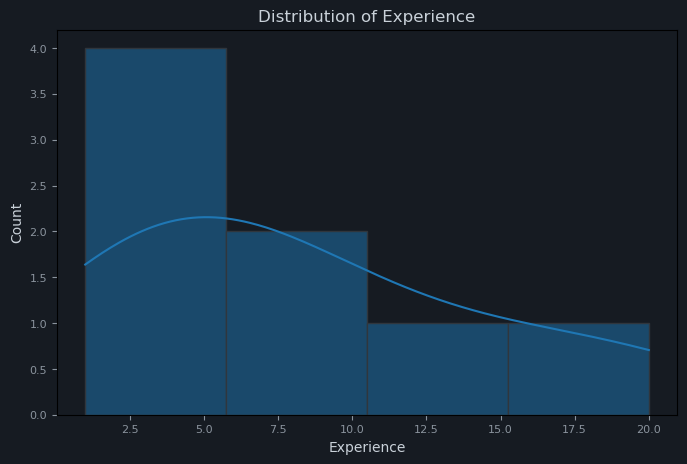
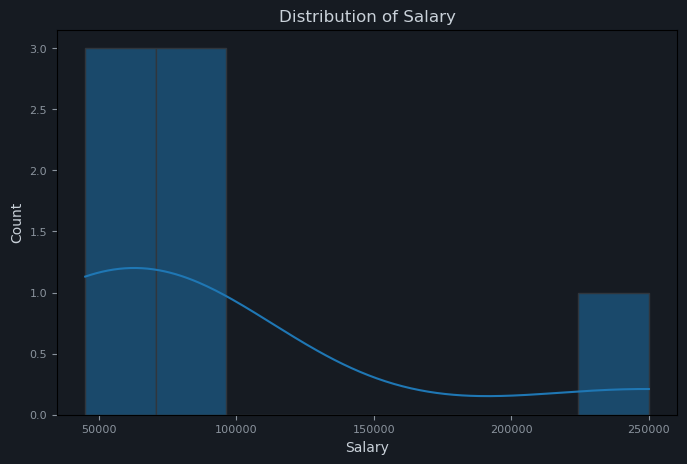
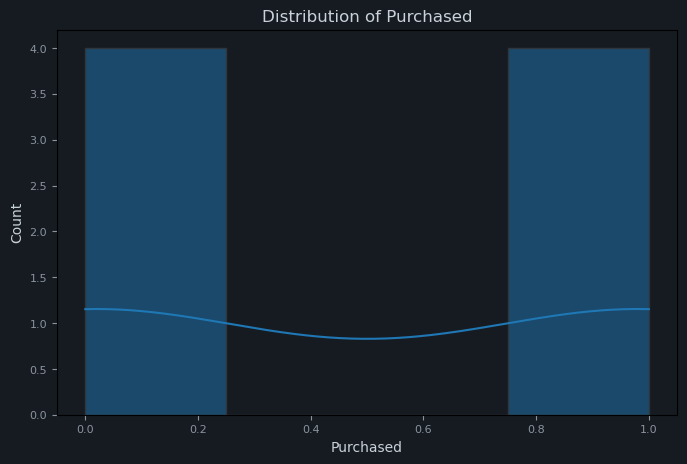
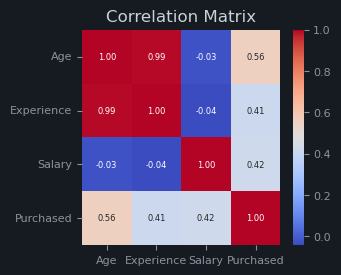

In [2]:
# Initialize AutoEDA with our data and target
eda = NoventisAutoEDA(data=df, target='Purchased')

# Run the analysis and display the report
eda.run()

In [3]:
# # Run the automated data cleaner
# cleaned_df = data_cleaner(data=df, target_column='Purchased')

# print("\nData After Cleaning:")
# display(cleaned_df.head())

In [4]:
cleaned_df = data_cleaner(data=df, target_column='Purchased', keep_target=True)

print("\nData After Cleaning (Target is kept):")
display(cleaned_df.head())

Target column 'Purchased' identified and separated.
STARTING NOVENTIS DATA CLEANER PIPELINE

Executing Step: IMPUTE...
Step IMPUTE Complete.

Executing Step: OUTLIER...
Step OUTLIER Complete.

Executing Step: ENCODE...
Step ENCODE Complete.

Executing Step: SCALE...
Step SCALE Complete.

PIPELINE FINISHED

====================== DATA QUALITY REPORT ======================
  Final Quality Score: 95.19/100
     - Completeness Score                 : 99.53      (Weight: 35%)
     - Data Consistency Score             : 89.25      (Weight: 0%)
     - Distribution Quality Score         : 94.76      (Weight: 20%)
     - Feature Engineering Score          : 97.50      (Weight: 15%)

PIPELINE PROCESS SUMMARY
  - Imputation: Successfully filled 3 missing values.
  - Outliers: Removed 1 rows and winsorized 0 rows identified as outliers.
  - Encoding: Transformed 1 categorical columns into 3 new features.
  - Scaling: Standardized the scale for 6 numerical columns.

Target column 'Purchased' has be

,Age,Experience,Salary,City_London,City_New York,City_Paris,Purchased
0,-1.352199,-1.121489,0.327353,1.154701,-0.632456,-0.632456,0
1,0.330538,0.263880,-1.141971,-0.866025,-0.632456,1.581139,1
2,-0.931515,-0.813629,-0.774640,-0.866025,1.581139,-0.632456,0
4,0.015024,-0.505769,0.511019,1.154701,-0.632456,-0.632456,1
5,-0.721173,-0.659699,1.403082,-0.866025,-0.632456,1.581139,0


In [5]:
# Initialize AutoML with the cleaned data
# We'll give it a 60-second time budget to find the best model
automl = NoventisAutoML(data=cleaned_df, 
                        target='Purchased', 
                        time_budget=60)

# Start the training and evaluation process
results = automl.fit()

INFO:flaml.automl.task.generic_task:class 0 augmented from 3 to 21
INFO:flaml.automl.task.generic_task:class 1 augmented from 2 to 20


✓ Data loaded from DataFrame
  Shape: (7, 7)
  Columns: ['Age', 'Experience', 'Salary', 'City_London', 'City_New York', 'City_Paris', 'Purchased']
✓ Task type auto-detected: classification
✓ Data split: Train=5, Test=2
Starting NoventisAutoML Training Process

[AutoML] Starting training...
  Metric: macro_f1
  Time Budget: 60s


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
INFO:root:NoventisManualML initialized for classification
INFO:root:Starting NoventisManualML Training Pipeline
INFO:root:No external DataCleaner provided. Using standard preprocessing.
INFO:root:Data split complete: Train=5, Test=2
INFO:root:Applying internal preprocessing (imputation + encoding)...
INFO:root:Numeric features: 6, Categorical features: 0
INFO:root:Preprocessing complete. Final shape: (5, 6)
INFO:root:Starting model training phase...
INFO:root:Training model 1/7: LOGISTIC_REGRESSION
INFO:root:Processing model: LOGISTIC_REGRESSION
INFO:root:Training finished in 0.02 seconds.
INFO:root:✓ LOGISTIC_REGRESSION trained successfully: accuracy=0.5000, precision=0.2500, r

✓ AutoML training completed
  Best estimator: lgbm

[Comparison] Comparing models...


INFO:root:Training finished in 0.25 seconds.
INFO:root:✓ RANDOM_FOREST trained successfully: accuracy=0.5000, precision=0.2500, recall=0.5000, f1_score=0.3333
INFO:root:Training model 3/7: XGBOOST
INFO:root:Processing model: XGBOOST
INFO:root:Training finished in 0.13 seconds.
INFO:root:✓ XGBOOST trained successfully: accuracy=0.5000, precision=0.2500, recall=0.5000, f1_score=0.3333
INFO:root:Training model 4/7: DECISION_TREE
INFO:root:Processing model: DECISION_TREE
INFO:root:Training finished in 0.00 seconds.
INFO:root:✓ DECISION_TREE trained successfully: accuracy=1.0000, precision=1.0000, recall=1.0000, f1_score=1.0000
INFO:root:Training model 5/7: LIGHTGBM
INFO:root:Processing model: LIGHTGBM
INFO:root:Training finished in 10.78 seconds.
INFO:root:✓ LIGHTGBM trained successfully: accuracy=0.5000, precision=0.2500, recall=0.5000, f1_score=0.3333
INFO:root:Training model 6/7: CATBOOST
INFO:root:Processing model: CATBOOST
INFO:root:Training finished in 2.05 seconds.
INFO:root:✓ CATBO

  ✓ Comparison report saved: Noventis_Results\model_comparison_report.txt
  Best model: Automl
  Score: 1.0000
  ✓ Model saved: Noventis_Results\best_model.pkl

[Explanation] Generating visualizations...
  ✓ Generated 6 visualization(s)
  ✓ Summary saved: Noventis_Results\model_summary.txt
  ✓ Summary report created
✓ Training completed successfully!
✓ Results saved to: Noventis_Results


In [6]:
automl.generate_html_report()